# 🎯 HỆ THỐNG QUẢN LÝ VÀ ĐÁNH GIÁ ĐỘ TIN CẬY TIN TUYỂN DỤNG

**Ứng dụng Machine Learning - Pipeline Hoàn Chỉnh**

---

## 📋 Tổng quan

### Mục tiêu
Xây dựng hệ thống tự động phát hiện tin tuyển dụng giả mạo sử dụng Machine Learning Ensemble.

### Pipeline
```
1. Preprocessing        → Làm sạch, tách từ tiếng Việt
2. Feature Engineering  → Trích xuất 30+ features
3. Multi-method Labeling → Rule-based + Anomaly Detection
4. Ensemble Training    → 5 models + Voting Ensemble
5. Evaluation          → Cross-validation, Metrics, Visualization
6. Deployment          → REST API với Flask
```

### Kết quả kỳ vọng
- **F1-Score**: 0.85 - 0.92
- **AUC-ROC**: 0.90 - 0.95
- **Precision**: 0.82 - 0.90

---

## 📦 Bước 0: Cài đặt và Import

### 📝 Giải thích
Cài đặt tất cả thư viện cần thiết cho toàn bộ pipeline.

In [1]:
# Cài đặt thư viện (chỉ chạy 1 lần)
!pip install pandas numpy scikit-learn scipy xgboost lightgbm pyvi matplotlib seaborn joblib flask flask-cors -q

print("✅ Đã cài đặt tất cả thư viện!")

✅ Đã cài đặt tất cả thư viện!



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# Import thư viện cơ bản
import pandas as pd
import numpy as np
import re
import warnings
from datetime import datetime
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

# Advanced ML
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Sparse matrices
from scipy.sparse import hstack

# Persistence
import joblib

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("✅ Import thành công!")
print(f"📅 Thời gian: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Import thành công!
📅 Thời gian: 2026-03-10 10:35:13


---

## 📂 Bước 1: Tiền xử lý dữ liệu (Preprocessing)

### 🎯 Mục tiêu
- Làm sạch văn bản (lowercase, loại ký tự đặc biệt)
- Tách từ tiếng Việt với PyVi
- Gộp các cột text thành FULL_TEXT

### 📊 Input
- File: `data/JOB_DATA_FINAL.csv`
- Columns: Job Title, Company Overview, Job Description, Requirements, Benefits, Salary, Company Size, Experience, Number Candidates

### 📤 Output
- File: `data/JOB_DATA_LABELLED.csv`
- New column: `FULL_TEXT`

In [3]:
# 1.1 Định nghĩa hàm làm sạch văn bản

def clean_text(text):
    """
    Làm sạch văn bản:
    - Chuyển về chữ thường
    - Xóa ký tự đặc biệt, giữ chữ cái và số
    - Xóa khoảng trắng dư thừa
    
    Args:
        text (str): Văn bản gốc
    
    Returns:
        str: Văn bản đã làm sạch
    """
    if not isinstance(text, str):
        return ""
    
    # Chuyển về lowercase
    text = text.lower()
    
    # Xóa ký tự đặc biệt, chỉ giữ chữ cái, số và khoảng trắng
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Xóa khoảng trắng dư thừa
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Test hàm
test_text = "Tuyển NHÂN VIÊN!!! Lương cao... 💰 Email: hr@company.com"
print(f"Original: {test_text}")
print(f"Cleaned:  {clean_text(test_text)}")

Original: Tuyển NHÂN VIÊN!!! Lương cao... 💰 Email: hr@company.com
Cleaned:  tuyển nhân viên lương cao email hr company com


In [4]:
# 1.2 Định nghĩa hàm tách từ tiếng Việt

from pyvi import ViTokenizer

def tokenize_vi(text):
    """
    Tách từ tiếng Việt với PyVi.
    Nối các từ ghép bằng dấu gạch dưới.
    
    VD: "tuyển dụng" → "tuyển_dụng"
        "nhân viên" → "nhân_viên"
    
    Args:
        text (str): Văn bản đã làm sạch
    
    Returns:
        str: Văn bản đã tách từ
    """
    return ViTokenizer.tokenize(text)

# Test hàm
test_text = "tuyển nhân viên kinh doanh tại hồ chí minh"
print(f"Original:  {test_text}")
print(f"Tokenized: {tokenize_vi(test_text)}")

Original:  tuyển nhân viên kinh doanh tại hồ chí minh
Tokenized: tuyển nhân_viên kinh_doanh tại hồ chí minh


In [6]:
# 1.3 Load dữ liệu gốc

print("📂 Đang load dữ liệu gốc...\n")

# Đọc file CSV
df = pd.read_csv("../data/JOB_DATA_FINAL.csv")

print(f"✅ Đã load {len(df)} mẫu dữ liệu")
print(f"\n📋 Shape: {df.shape}")
print(f"\n📊 Các cột trong data:")
print(df.columns.tolist())

# Xem 5 mẫu đầu
print(f"\n👀 5 mẫu đầu tiên:")
df.head()

📂 Đang load dữ liệu gốc...

✅ Đã load 14634 mẫu dữ liệu

📋 Shape: (14634, 19)

📊 Các cột trong data:
['JobID', 'URL Job', 'Job Title', 'Name Company', 'Company Overview', 'Company Size', 'Company Address', 'Job Description', 'Job Requirements', 'Benefits', 'Job Address', 'Job Type', 'Gender', 'Number Cadidate', 'Career Level', 'Years of Experience', 'Salary', 'Submission Deadline', 'Industry']

👀 5 mẫu đầu tiên:


,JobID,URL Job,Job Title,Name Company,Company Overview,Company Size,Company Address,Job Description,Job Requirements,Benefits,Job Address,Job Type,Gender,Number Cadidate,Career Level,Years of Experience,Salary,Submission Deadline,Industry
0,0,https://www.topcv.vn/viec-lam/sale-admin-websi...,Sale Admin Website,Công ty Cổ phần Belie,DHC Việt Nam trực thuộc Công ty CP Belie – Nhà...,100-499,"HN: Tầng 9, Tòa IDMC Mỹ Đình, 18 Tôn Thất Thuy...",Thường xuyên cập nhật các thay đổi liên quan t...,"1. Học vấn, kiến thức và trình độ chuyên môn:T...",Được xét duyệt đánh giá định kỳ 2 lần/năm.Làm ...,Hà Nội,Full time,Không yêu cầu,1,Nhân viên,1-3 năm,"5,000,000 - 10,000,000",05/01/2023,Hành chính / Văn phòng
1,1,https://www.topcv.vn/viec-lam/thuc-tap-sinh-la...,"Thực Tập Sinh Lập Trình (No-Code, Low-Code Pla...",Công Ty Cổ Phần Global Online Branding,Thành viên thuộc Tập đoàn G-Group:Công ty Cổ p...,100-499,"Lầu 6, 235 Lý Thường Kiệt ,Phường 6 ,Quận Tân ...","Phối hợp với bộ phận lập trình No-code, Low-co...","Sinh viên năm 3, năm 4 hoặc sinh viên cao học ...",Làm việc trong môi trường văn hóa Nhật Bản chu...,Hồ Chí Minh,Full time,Không yêu cầu,2,Thực tập sinh,Không yêu cầu kinh nghiệm,"1,000,000 - 5,000,000",01/01/2023,Công nghệ thông tin
2,2,https://www.topcv.vn/viec-lam/hr-business-part...,HR Business Partner,Công Ty Melody Logistics,Công Ty TNHH Melody Logistics được biết đến là...,100-499,"Số 01 Nguyễn Văn Đậu Phường 5, Quận Phú Nhuận,...",Xây dựng và thực hiện chiến lược nhân sự phù h...,Tốt nghiệp đại học các chuyên ngành liên quan ...,Lương thỏa thuận theo năng lực;Làm việc trong ...,Hồ Chí Minh,Full time,Không yêu cầu,1,Trưởng/Phó phòng,5-10 năm,Thỏa thuận,28/12/2022,Nhân sự
3,3,https://www.topcv.vn/viec-lam/general-manager/...,General Manager,CÔNG TY TNHH DV HOLDINGS,"Khách sạn Danaciti By Dabi là khách sạn 4 sao,...",25-99,"80 Đông Kinh Nghĩa Thục, Sơn Trà, Đà Nẵng",1. Lập và triển khai kế hoạch kinh doanh- Định...,- Tốt nghiệp đại học trở lên chuyên ngành quản...,"- Tiền lương, thưởng và các khoản trợ cấp khác...",Đà Nẵng,Full time,Không yêu cầu,1,Giám đốc,3-5 năm,Thỏa thuận,31/12/2022,Khách sạn / Nhà hàng
4,4,https://www.topcv.vn/viec-lam/le-tan-gymasaste...,Lễ Tân Gymasaster Quận 12,CÔNG TY TNHH TM XNK NGUỒN SỐNG VIỆT,Công ty TNHH TM XNK Nguồn Sống Việt cung câ...,100-499,"235 đường 9A, khu dân cư Trung Sơn, huyện Bi...",- Trực quầy Lễ tân- Tư vấn bán hàng gói member...,- Giới tính: Ưu tiên Nữ từ 22 - 35 tuổi- Kinh ...,Thu nhập = Lương cơ bản + Thưởng KPIs + Hoa hồ...,Hồ Chí Minh,Full time,Không yêu cầu,2,Nhân viên,Không yêu cầu kinh nghiệm,"5,000,000 - 10,000,000",06/01/2023,Hành chính / Văn phòng


In [7]:
# 1.4 Kiểm tra missing values

print("🔍 Kiểm tra missing values:\n")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

# Visualize
if missing_df['Missing Count'].sum() > 0:
    plt.figure(figsize=(10, 4))
    missing_df[missing_df['Missing Count'] > 0]['Percentage'].plot(kind='barh')
    plt.xlabel('Tỷ lệ missing (%)')
    plt.title('Missing Values trong Dataset')
    plt.tight_layout()
    plt.show()

🔍 Kiểm tra missing values:

Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []


In [8]:
# 1.5 Tiền xử lý từng cột text

print("🔧 Đang tiền xử lý các cột văn bản...\n")

# Các cột văn bản cần xử lý
text_cols = [
    'Job Title',
    'Company Overview',
    'Job Description',
    'Job Requirements',
    'Benefits'
]

# Xử lý từng cột
for col in text_cols:
    if col in df.columns:
        print(f"  ⚙️ Xử lý cột: {col}")
        
        # Bước 1: Điền NaN bằng chuỗi rỗng
        df[col] = df[col].fillna("")
        
        # Bước 2: Làm sạch
        df[col] = df[col].apply(clean_text)
        
        # Bước 3: Tách từ tiếng Việt
        df[col] = df[col].apply(tokenize_vi)

print("\n✅ Hoàn thành tiền xử lý!")

🔧 Đang tiền xử lý các cột văn bản...

  ⚙️ Xử lý cột: Job Title
  ⚙️ Xử lý cột: Company Overview
  ⚙️ Xử lý cột: Job Description
  ⚙️ Xử lý cột: Job Requirements
  ⚙️ Xử lý cột: Benefits

✅ Hoàn thành tiền xử lý!


In [9]:
# 1.6 Xem kết quả tiền xử lý

print("👀 Ví dụ sau tiền xử lý:\n")

sample_idx = 0
for col in text_cols:
    if col in df.columns:
        sample_text = df[col].iloc[sample_idx]
        print(f"\n{col}:")
        print(f"  {sample_text[:150]}..." if len(sample_text) > 150 else f"  {sample_text}")

👀 Ví dụ sau tiền xử lý:


Job Title:
  sale admin website

Company Overview:
  dhc việt nam trực_thuộc công_ty cp belie nhà phân_phối độc_quyền mỹ_phẩm và thực_phẩm chức_năng dhc nhật bản tại việt_nam với sứ_mệnh triết_lý kinh_do...

Job Description:
  thường_xuyên cập_nhật các thay_đổi liên_quan trong chính_sách bán hàng chương_trình khuyến_mại của công tylàm việc với các đối_tác_chiến_lược mang lại...

Job Requirements:
  1 học_vấn kiến_thức và trình_độ chuyên_môn tốt_nghiệp đại_học cao đẳng2 kinh_nghiệm ứng_viên có kinh_nghiệm 1 2 năm tại vị_trí tương tựưu tiên ứng_viê...

Benefits:
  được xét_duyệt đánh_giá định_kỳ 2 lần năm làm_việc từ thứ 2 sáng thứ 7được hưởng các quyền_lợi và chế_độ theo luật quy_định các ngày nghỉ lễ bhxh bhyt...


🔗 Đang gộp các cột text thành FULL_TEXT...

✅ Đã tạo cột FULL_TEXT

📊 Thống kê độ dài text:
count    14634.000000
mean       323.211630
std        171.981271
min          7.000000
25%        201.000000
50%        294.000000
75%        410.000000
max       3504.000000
Name: text_word_count, dtype: float64


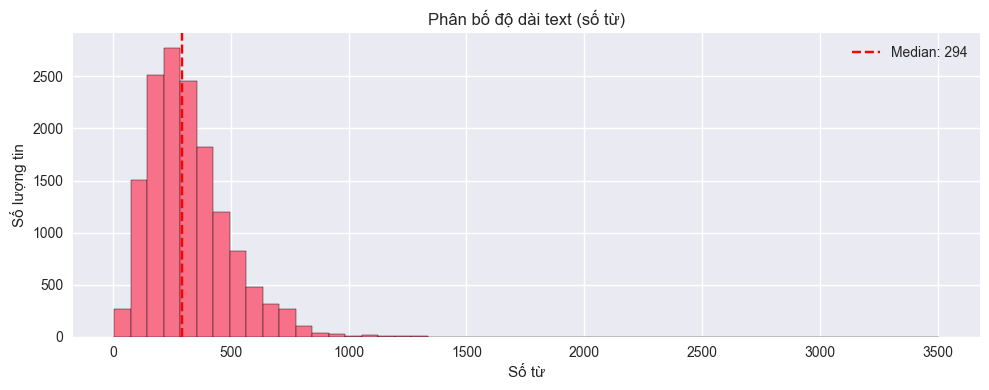


👀 Ví dụ FULL_TEXT:
sale admin website dhc việt nam trực_thuộc công_ty cp belie nhà phân_phối độc_quyền mỹ_phẩm và thực_phẩm chức_năng dhc nhật bản tại việt_nam với sứ_mệnh triết_lý kinh_doanh cung_cấp những sản_phẩm thực và chất với chất_lượng dịch_vụ dẫn_đầu và giá_thành hợp_lý nhất cho người tiêu_dùng việt nam đem l...


In [10]:
# 1.7 Gộp các cột text thành FULL_TEXT

print("🔗 Đang gộp các cột text thành FULL_TEXT...\n")

# Gộp tất cả text columns
df['FULL_TEXT'] = (
    df['Job Title'] + ' ' +
    df['Company Overview'] + ' ' +
    df['Job Description'] + ' ' +
    df['Job Requirements'] + ' ' +
    df['Benefits']
)

# Thống kê
df['text_word_count'] = df['FULL_TEXT'].str.split().str.len()

print(f"✅ Đã tạo cột FULL_TEXT")
print(f"\n📊 Thống kê độ dài text:")
print(df['text_word_count'].describe())

# Visualize distribution
plt.figure(figsize=(10, 4))
plt.hist(df['text_word_count'], bins=50, edgecolor='black')
plt.xlabel('Số từ')
plt.ylabel('Số lượng tin')
plt.title('Phân bố độ dài text (số từ)')
plt.axvline(df['text_word_count'].median(), color='red', linestyle='--', label=f'Median: {df["text_word_count"].median():.0f}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n👀 Ví dụ FULL_TEXT:")
print(df['FULL_TEXT'].iloc[0][:300] + "...")

In [12]:
# 1.8 Lưu kết quả preprocessing

# Chọn các cột cần thiết cho bước tiếp theo
final_cols = [
    'FULL_TEXT',
    'Job Title',
    'Company Overview',
    'Job Description',
    'Job Requirements',
    'Benefits',
    'Company Size',
    'Years of Experience',
    'Number Cadidate',
    'Salary'
]

df_final = df[final_cols].copy()

# Lưu file
df_final.to_csv(
    "../data/JOB_DATA_LABELLED.csv",
    index=False,
    encoding="utf-8-sig"
)

print("💾 Đã lưu file: data/JOB_DATA_LABELLED.csv")
print(f"📊 Shape: {df_final.shape}")
print(f"\n✅ Checkpoint 1 hoàn thành!\n")

df_final.head()

💾 Đã lưu file: data/JOB_DATA_LABELLED.csv
📊 Shape: (14634, 10)

✅ Checkpoint 1 hoàn thành!



,FULL_TEXT,Job Title,Company Overview,Job Description,Job Requirements,Benefits,Company Size,Years of Experience,Number Cadidate,Salary
0,sale admin website dhc việt nam trực_thuộc côn...,sale admin website,dhc việt nam trực_thuộc công_ty cp belie nhà p...,thường_xuyên cập_nhật các thay_đổi liên_quan t...,1 học_vấn kiến_thức và trình_độ chuyên_môn tốt...,được xét_duyệt đánh_giá định_kỳ 2 lần năm làm_...,100-499,1-3 năm,1,"5,000,000 - 10,000,000"
1,thực_tập_sinh lập_trình no code low code platf...,thực_tập_sinh lập_trình no code low code platform,thành_viên thuộc tập_đoàn g group công_ty cổ_p...,phối_hợp với bộ_phận lập_trình no code low cod...,sinh_viên năm 3 năm 4 hoặc sinh_viên cao_học n...,làm_việc trong môi_trường văn_hóa nhật bản chu...,100-499,Không yêu cầu kinh nghiệm,2,"1,000,000 - 5,000,000"
2,hr business partner công_ty_tnhh melody logist...,hr business partner,công_ty_tnhh melody logistics được biết đến là...,xây_dựng và thực_hiện chiến_lược nhân_sự phù_h...,tốt_nghiệp đại_học các chuyên_ngành liên_quan ...,lương thỏa_thuận theo năng_lực làm_việc trong ...,100-499,5-10 năm,1,Thỏa thuận
3,general manager khách_sạn danaciti by dabi là ...,general manager,khách_sạn danaciti by dabi là khách_sạn 4 sao ...,1 lập và triển_khai kế_hoạch kinh_doanh định_k...,tốt_nghiệp đại_học trở lên chuyên_ngành quản_t...,tiền_lương thưởng và các khoản trợ_cấp khác sẽ...,25-99,3-5 năm,1,Thỏa thuận
4,lê tân gymasaster quâ n 12 công_ty_tnhh tm xnk...,lê tân gymasaster quâ n 12,công_ty_tnhh tm xnk nguô n sô ng viê t cung câ...,trực quầy lễ_tân tư_vấn bán hàng gói membershi...,giới_tính ưu_tiên_nữ từ 22 35 tuổi kinh_nghiệm...,thu_nhập lương cơ_bản thưởng kpis hoa_hồng các...,100-499,Không yêu cầu kinh nghiệm,2,"5,000,000 - 10,000,000"


### ✅ Checkpoint 1: Hoàn thành Preprocessing

**Đã làm:**
- ✅ Làm sạch văn bản (lowercase, remove special chars)
- ✅ Tách từ tiếng Việt với PyVi
- ✅ Gộp text thành FULL_TEXT
- ✅ Lưu file: `JOB_DATA_LABELLED.csv`

**Tiếp theo:**
- ➡️ Bước 2: Feature Engineering (trích xuất 30+ features)

---

## 🔧 Bước 2: Feature Engineering

### 🎯 Mục tiêu
Tăng từ **5 features cơ bản** → **30+ features chất lượng cao**

### 📊 Nhóm features
1. **Text Features** (10+): độ dài, từ vựng, chữ hoa, scam keywords, positive keywords
2. **Salary Features** (6+): mức lương avg, nghi ngờ cao/thấp, negotiable
3. **Company Features** (5+): quy mô công ty, thông tin công ty
4. **Requirement Features** (6+): kinh nghiệm, số lượng tuyển, yêu cầu

### 💡 Ý tưởng
- **Scam keywords**: "việc nhẹ lương cao", "không cần kinh nghiệm", "thu nhập không giới hạn"
- **Positive keywords**: "bảo hiểm", "hợp đồng", "phụ cấp", "đào tạo"
- **Salary patterns**: Phát hiện lương bất thường cao (>50M) hoặc quá thấp (<3M)